In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, datasets, transforms
import timm
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import sys
print(sys.executable)

/home/iztihad/venvs/ml/bin/python


In [3]:
model_config = {
    "batch_size": 16,
    "input_size": 224,
    "architecture": "tiny-vision-transformer",
    "learning_rate": 0.001,
    "epochs": 20,
    "pretrained":True
}

In [4]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ]),

    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ]),

    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ])
}

train_dir = "../BanglaLekha_dataset_split/train"
val_dir = "../BanglaLekha_dataset_split/validation"
test_dir = "../BanglaLekha_dataset_split/test"


train_dataset = datasets.ImageFolder(root=train_dir, transform=data_transforms["train"])
val_dataset = datasets.ImageFolder(root=val_dir, transform=data_transforms["val"])
test_dataset = datasets.ImageFolder(root=test_dir, transform=data_transforms["test"])

train_dataloader = DataLoader(train_dataset, batch_size=model_config["batch_size"], shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=model_config["batch_size"], shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=model_config["batch_size"], shuffle=False)

In [5]:

tiny_vit = timm.create_model("tiny_vit_11m_224", pretrained=True)

for params in tiny_vit.parameters():
    params.requires_grad = False

tiny_vit.reset_classifier(84)


total_params_tiny = sum(p.numel() for p in tiny_vit.parameters())

gpu = torch.device("cuda")
tiny_vit = tiny_vit.to(gpu)


In [7]:

efficientnet_b2 = models.efficientnet_b2(pretrained=True)


for param in efficientnet_b2.parameters():
    param.requires_grad = False

in_features = efficientnet_b2.classifier[1].in_features
efficientnet_b2.classifier[1] = nn.Linear(in_features, 84)

total_params_eff4 = sum(p.numel() for p in efficientnet_b2.parameters())

gpu = torch.device("cuda")
efficientnet_b2 = efficientnet_b2.to(gpu)


In [8]:
print(total_params_tiny + total_params_eff4)

18405038


In [41]:
def validate_model(model1, model2, val_dataloader, factor):
    with torch.no_grad():
        model1.eval()
        model2.eval()
        total = 0
        total_correct = 0

        class_freq = np.zeros(84, dtype=int)
        class_corr_freq = np.zeros(84, dtype=int)

        for images, labels in val_dataloader:
            images = images.to(gpu)
            labels = labels.to(gpu)

            output1 = model1(images)
            output2 = model2(images)
            
            output = factor*output1 + (1-factor)*output2
            _, predicted = torch.max(output, 1)

            total = total + len(labels)
            # print(predicted.shape)
            # print(labels.shape)

            for i in range(0, predicted.size(0)):
                class_freq[labels[i]]+=1
                if(predicted[i] == labels[i]):
                    total_correct+=1
                    class_corr_freq[predicted[i]]+=1

            # total_correct = total_correct + (predicted == labels).sum().item()

        return total_correct/total, class_freq, class_corr_freq



In [10]:
tiny_vit.load_state_dict(torch.load("saved_parameters/tiny_ViT.pth"))
tiny_vit.eval()

TinyVit(
  (patch_embed): PatchEmbed(
    (conv1): ConvNorm(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (act): GELU(approximate='none')
    (conv2): ConvNorm(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (stages): Sequential(
    (0): ConvLayer(
      (blocks): Sequential(
        (0): MBConv(
          (conv1): ConvNorm(
            (conv): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (act1): GELU(approximate='none')
          (conv2): ConvNorm(
            (conv): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=256, bias=Fals

In [11]:
efficientnet_b2.load_state_dict(torch.load("saved_parameters/efficientnet_b2.pth"))
efficientnet_b2.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [42]:
max_accuracy = 0
classwise_accuracy = np.array([])
for factor in np.arange(0.45, 0.6, 0.01):
    accuracy, class_freq, class_corr_freq = validate_model(tiny_vit, efficientnet_b2, test_dataloader, factor)
    if(accuracy > max_accuracy):
        max_accuracy = accuracy
        classwise_accuracy = (class_corr_freq/class_freq)

print(f"Accuracy: {100 * max_accuracy: 0.2f}")


Accuracy:  95.02


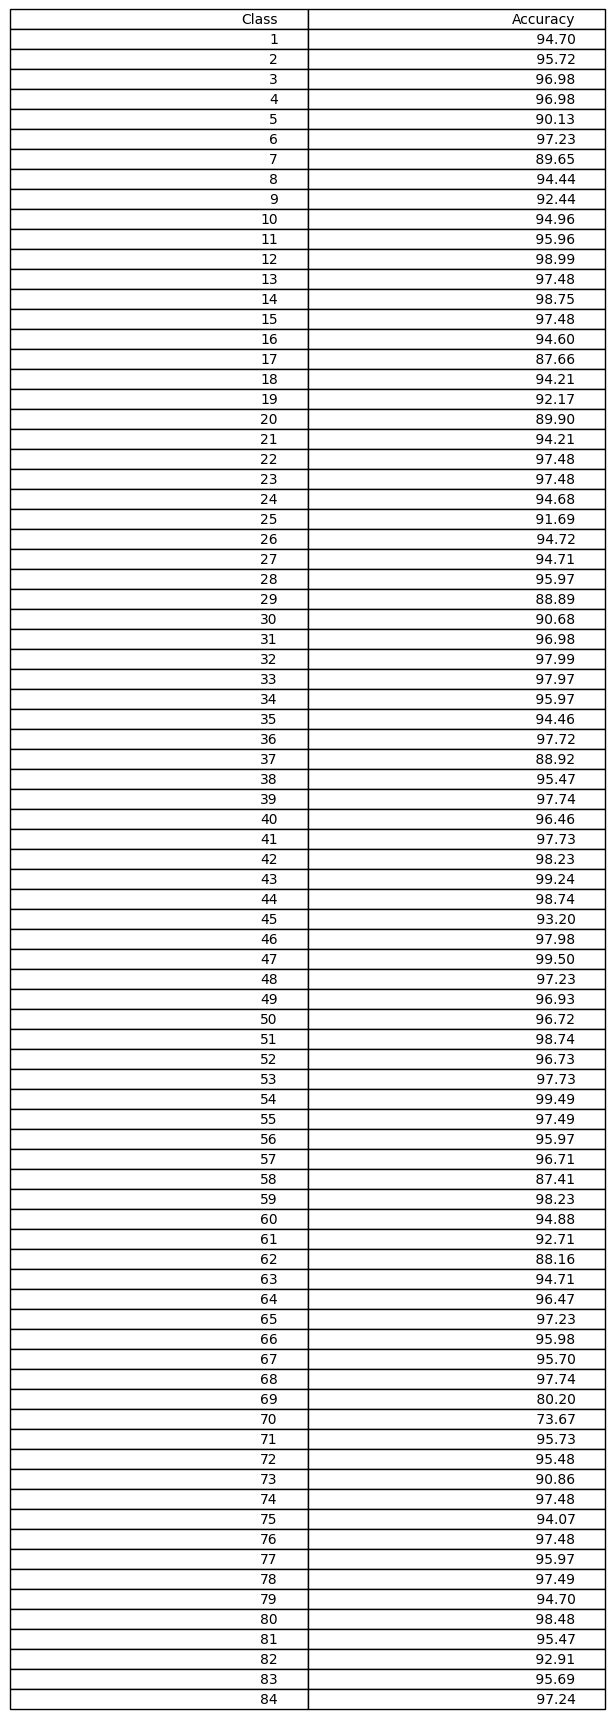

In [43]:


table_data = [["Class", "Accuracy"]] 
for i, val in enumerate(classwise_accuracy):
    table_data.append([i+1, f"{100*val: 0.2f}"])


fig, ax = plt.subplots()
ax.axis('off')  

table = ax.table(cellText=table_data, loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.show()